In [1]:
using PyPlot
using JLD2
using Statistics
using ProgressBars

In [2]:
function mask_ellipse(xc, yc, a, b, θ, width, height)
    mask = zeros(Integer, (width, height))
    X = range(0, height-1) .- yc
    Y = range(0, width-1) .- xc
    for (i, x) in enumerate(X)
        for (j, y) in enumerate(Y)
            # Rotate back
            x_hor = x*sin(θ) + y*cos(θ)
            y_hor = x*cos(θ) - y*sin(θ)
            if (x_hor/a)^2 + (y_hor/b)^2 ≤ 1
                mask[i, j] = 1
            end
        end
    end
    return mask
end

function mask_droplets(img, centers, radius_droplets)
    mask = zeros(size(img))
    for c in centers
        mask .+= mask_ellipse(c[1], c[2], radius_droplets, radius_droplets, 0, size(img)[1], size(img)[2])
    end
    mask[mask .> 0] .= true
    return img.*mask
end

mask_droplets (generic function with 1 method)

In [3]:
pathdir = "Y:/TwoDGas/2025/07/04"
# pathdir = "Y:/TwoDGas/2026/01/19/0046"
# pathdir = "Y:/TwoDGas/2026/01/19/0047"
# pathdir = "Y:/StructuralPhaseTransition/2026/02/02/0000" # Tilted droplets, 15°

@load "Saved_exp_data/Imgs_croped_"*join(split(pathdir, "/")[3:end], "_")*".jld2" Sat τ_exp Imgs_atoms_crop_ds Imgs_bkg_crop_ds Imgs_dark_crop_ds
@load "Saved_exp_data/Droplets_"*join(split(pathdir, "/")[3:end], "_")*".jld2" centers_droplets_ds nbr_droplets_ds
radius_droplets = 12 # In pxls
size_pxl = 0.187e-6
# N_atoms_per_droplet = 15000;

1.87e-7

### Check validity of droplet region

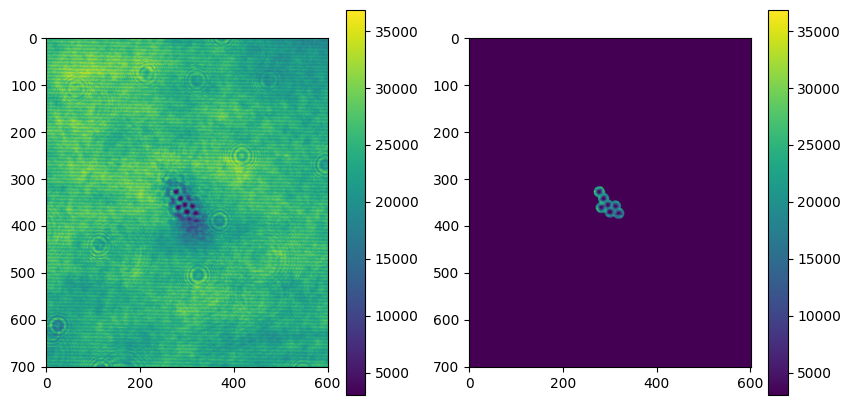

In [4]:
i, j = 4, 3

close("all")
fig, axs = subplots(1, 2, figsize=(10, 5))

img1 = axs[1].imshow(Imgs_atoms_crop_ds[i, j, :, :])
colorbar(img1)

img2 = axs[2].imshow(mask_droplets(Imgs_atoms_crop_ds[i, j, :, :], centers_droplets_ds[i][j], radius_droplets), vmin=minimum(Imgs_atoms_crop_ds[i, j, :, :]), vmax=maximum(Imgs_atoms_crop_ds[i, j, :, :]))
colorbar(img2)

# pygui(true); show()
pygui(false);

### Intensity integrated over the droplets

In [5]:
Iatoms_drop, Ibkg_drop, Idark_drop = zeros(size(Imgs_atoms_crop_ds)[1:2]), zeros(size(Imgs_atoms_crop_ds)[1:2]), zeros(size(Imgs_atoms_crop_ds)[1:2])

# Convertion factor to go from electrons to photons
if length(τ_exp) == 1
    Convertion_factor = 0.107 / (0.85 * τ_exp)
end

for i = ProgressBar(1:length(Sat))
    if length(τ_exp) > 1
        Convertion_factor = 0.107 / (0.85 * τ_exp[i])
    end

    for j = 1:size(Imgs_atoms_crop_ds)[2]
        if nbr_droplets_ds[i, j] > 0
            Iatoms_drop[i, j] = sum(mask_droplets(Imgs_atoms_crop_ds[i, j, :, :], centers_droplets_ds[i][j], radius_droplets))/nbr_droplets_ds[i, j]
            Ibkg_drop[i, j] = sum(mask_droplets(Imgs_bkg_crop_ds[i, j, :, :], centers_droplets_ds[i][j], radius_droplets))/nbr_droplets_ds[i, j]
            Idark_drop[i, j] = sum(mask_droplets(Imgs_dark_crop_ds[i, j, :, :], centers_droplets_ds[i][j], radius_droplets))/nbr_droplets_ds[i, j]
        end
        
        Iatoms_drop[i, j] *= Convertion_factor
        Ibkg_drop[i, j] *= Convertion_factor
        Idark_drop[i, j] *= Convertion_factor
    end
end

# Iatoms_drop /= N_atoms_per_droplet
# Ibkg_drop /= N_atoms_per_droplet
# Idark_drop /= N_atoms_per_droplet

# Convert to photon/m^2
S_droplet = π*(radius_droplets*size_pxl)^2
Iatoms_drop /= S_droplet
Ibkg_drop /= S_droplet
Idark_drop /= S_droplet;

0.0%┣                                               ┫ 0/6 [00:02<00:-10, -2s/it]
16.7%┣███████▏                                   ┫ 1/6 [00:26<Inf:Inf, InfGs/it]
33.3%┣███████████████▊                               ┫ 2/6 [00:50<03:19, 50s/it]
50.0%┣███████████████████████▌                       ┫ 3/6 [01:14<01:51, 37s/it]
66.7%┣███████████████████████████████▍               ┫ 4/6 [01:41<01:08, 34s/it]
83.3%┣███████████████████████████████████████▏       ┫ 5/6 [02:09<00:32, 32s/it]
100.0%┣██████████████████████████████████████████████┫ 6/6 [02:37<00:00, 31s/it]
100.0%┣██████████████████████████████████████████████┫ 6/6 [02:37<00:00, 31s/it]


### Compute mean/std

In [6]:
Mean_atoms, Mean_bkg, Mean_dark, Mean_bkg_atoms = zeros(length(Sat)), zeros(length(Sat)), zeros(length(Sat)), zeros(length(Sat))
Std_atoms, Std_bkg, Std_dark, Std_bkg_atoms = zeros(length(Sat)), zeros(length(Sat)), zeros(length(Sat)), zeros(length(Sat))

for i = 1:length(Sat)
    atoms, bkg, dark, bkg_atoms = [], [], [], []
    for j = 1:size(Imgs_atoms_crop_ds)[2]
        if nbr_droplets_ds[i, j] > 0
            push!(atoms, Iatoms_drop[i, j]), push!(bkg, Ibkg_drop[i, j]), push!(dark, Idark_drop[i, j]), push!(bkg_atoms, Ibkg_drop[i, j]-Iatoms_drop[i, j])
        end
    end
    if length(atoms) > 0
        Mean_atoms[i], Mean_bkg[i], Mean_dark[i], Mean_bkg_atoms[i] = mean(atoms), mean(bkg), mean(dark), mean(bkg_atoms)
        Std_atoms[i], Std_bkg[i], Std_dark[i], Std_bkg_atoms[i] = std(atoms), std(bkg), std(dark), std(bkg_atoms)
    end
end

## Plots

In [ ]:
close("all")
fig = subplots()

errorbar(Sat, Mean_atoms, yerr=Std_atoms, label="Atoms")
errorbar(Sat, Mean_bkg, yerr=Std_bkg, label="Bkg")
errorbar(Sat, Mean_dark, yerr=Std_dark, label="Dark", color="grey")
errorbar(Sat, Mean_bkg_atoms, yerr=Std_bkg_atoms, label="Bkg-atoms", color="g")


for i in 1:length(Sat)
    for j in 1:size(Imgs_atoms_crop_ds)[2]
        scatter(Sat[i], Iatoms_drop[i, j], color="b", alpha = 0.1)
        scatter(Sat[i], Ibkg_drop[i, j], color="r", alpha = 0.1)
        scatter(Sat[i], Idark_drop[i, j], color="grey")
        scatter(Sat[i], Ibkg_drop[i, j]-Iatoms_drop[i, j], color="g", alpha = 0.1)
    end
end

xlabel(L"s")
ylabel(L"I_{droplet}")

legend()

# pygui(true); show();
pygui(false);

In [ ]:
close("all")
fig = subplots()

errorbar(Sat, Mean_bkg_atoms, yerr=Std_bkg_atoms, label="Bkg-atoms", color="g")

for i in 1:length(Sat)
    for j in 1:size(Imgs_atoms_crop_ds)[2]
        scatter(Sat[i], Ibkg_drop[i, j]-Iatoms_drop[i, j], color="g", alpha = 0.1)
    end
end

xlabel(L"s")
ylabel(L"I_{droplet}")

legend()

# pygui(true); show();
pygui(false);

In [ ]:
close("all")
fig = subplots()

errorbar(Sat, Mean_atoms, yerr=Std_atoms, label="Atoms")


for i in 1:length(Sat)
    for j in 1:size(Imgs_atoms_crop_ds)[2]
        scatter(Sat[i], Iatoms_drop[i, j], color="b", alpha = 0.1)
    end
end

xlabel(L"s")
ylabel(L"I_{droplet}")

legend()

# pygui(true); show();
pygui(false);

### Save data

In [ ]:
@save "Saved_exp_data/Intensity_integrated_droplets_"*join(split(pathdir, "/")[3:end], "_")*".jld2" Sat Iatoms_drop Ibkg_drop Idark_drop Mean_atoms Mean_bkg Mean_dark Mean_bkg_atoms Std_atoms Std_bkg Std_dark Std_bkg_atoms;

### Plot as a function of the calculated saturation parameter

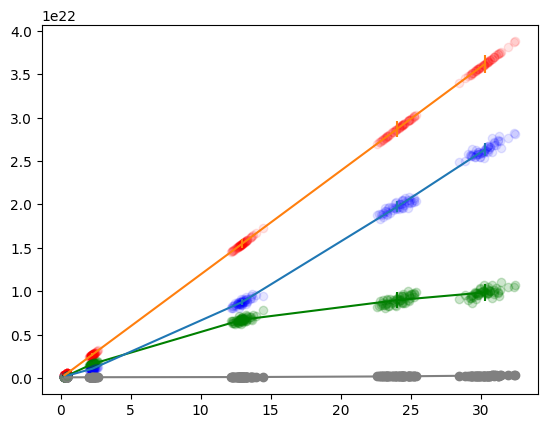

In [7]:
import PhysicalConstants.CODATA2018: c_0, ħ
using Unitful

Γ = 2.02e8 # In Hz
λ = 421e-9
ω0 = 2π*ustrip(c_0)/λ

# Isat = ustrip(ħ)*Γ*ω0^3 / (12*π*ustrip(c_0)^2)
# Isat /= ustrip(ħ)*ω0*N_atoms_per_droplet; # Convert to photon/m^2/atom
Isat = Γ*ω0^2 / (12*π*ustrip(c_0)^2) # In photon/m^2

errorbar(Mean_bkg/Isat, Mean_bkg_atoms, yerr=Std_bkg, label="Bkg-atoms", color="green")
errorbar(Mean_bkg/Isat, Mean_atoms, yerr=Std_atoms, label="Atoms")
errorbar(Mean_bkg/Isat, Mean_bkg, yerr=Std_bkg, label="Bkg")
errorbar(Mean_bkg/Isat, Mean_dark, yerr=Std_dark, label="Dark", color="grey")

for i = 1:size(Iatoms_drop)[1]
    for j = 1:size(Iatoms_drop)[2]
        scatter(Ibkg_drop[i, j]/Isat, Ibkg_drop[i, j]-Iatoms_drop[i, j], color="g", alpha = 0.1)
        scatter(Ibkg_drop[i, j]/Isat, Iatoms_drop[i, j], color="b", alpha = 0.1)
        scatter(Ibkg_drop[i, j]/Isat, Ibkg_drop[i, j], color="r", alpha = 0.1)
        scatter(Ibkg_drop[i, j]/Isat, Idark_drop[i, j], color="grey")
        scatter(Ibkg_drop[i, j]/Isat, Ibkg_drop[i, j]-Iatoms_drop[i, j], color="g", alpha = 0.1)
    end
end